First 5 rows:
  Soil_Type    pH    EC  Organic_Carbon  Nitrogen  Phosphorus  Potassium  \
0      Clay  4.91  1.33            0.96        84          74        531   
1     Sandy  8.63  1.53            0.80       297          65        432   
2      Clay  5.12  2.19            0.89        90          30        528   
3      Clay  8.78  2.46            1.09       406          75         68   
4     Sandy  6.51  1.14            0.54       196          87         78   

   Moisture  Temperature Soil_Quality  
0     15.66        29.19         Poor  
1     14.14        12.02         Good  
2     36.62        17.59         Poor  
3     42.46        34.24         Good  
4     26.04        15.01     Moderate  

Dataset Shape:
(1500, 10)

Number of Rows: 1500
Number of Columns: 10

Column Names:
['Soil_Type', 'pH', 'EC', 'Organic_Carbon', 'Nitrogen', 'Phosphorus', 'Potassium', 'Moisture', 'Temperature', 'Soil_Quality']

Dataset Information:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1500 

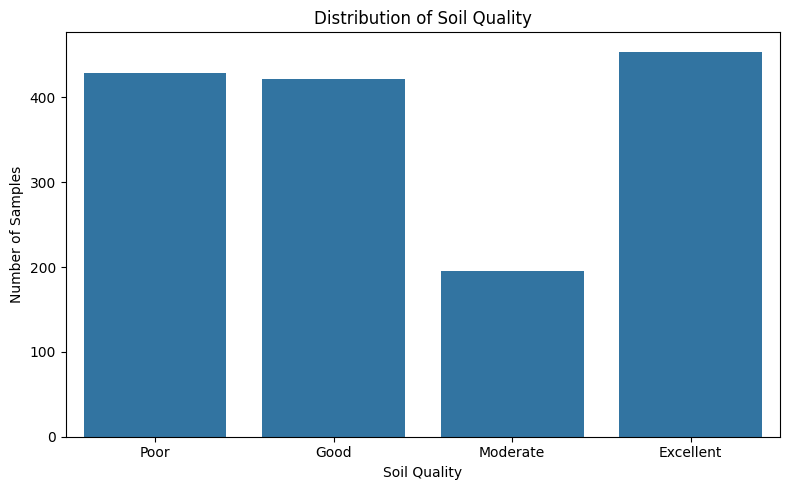

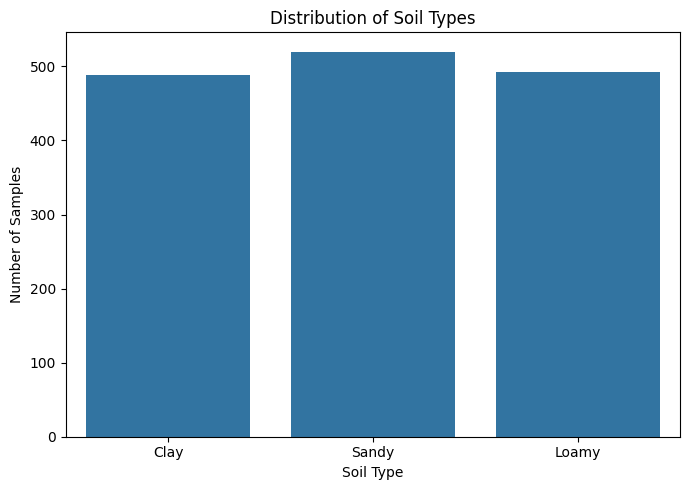


Numerical Features:
['pH', 'EC', 'Organic_Carbon', 'Nitrogen', 'Phosphorus', 'Potassium', 'Moisture', 'Temperature']

Number of Numerical Features: 8


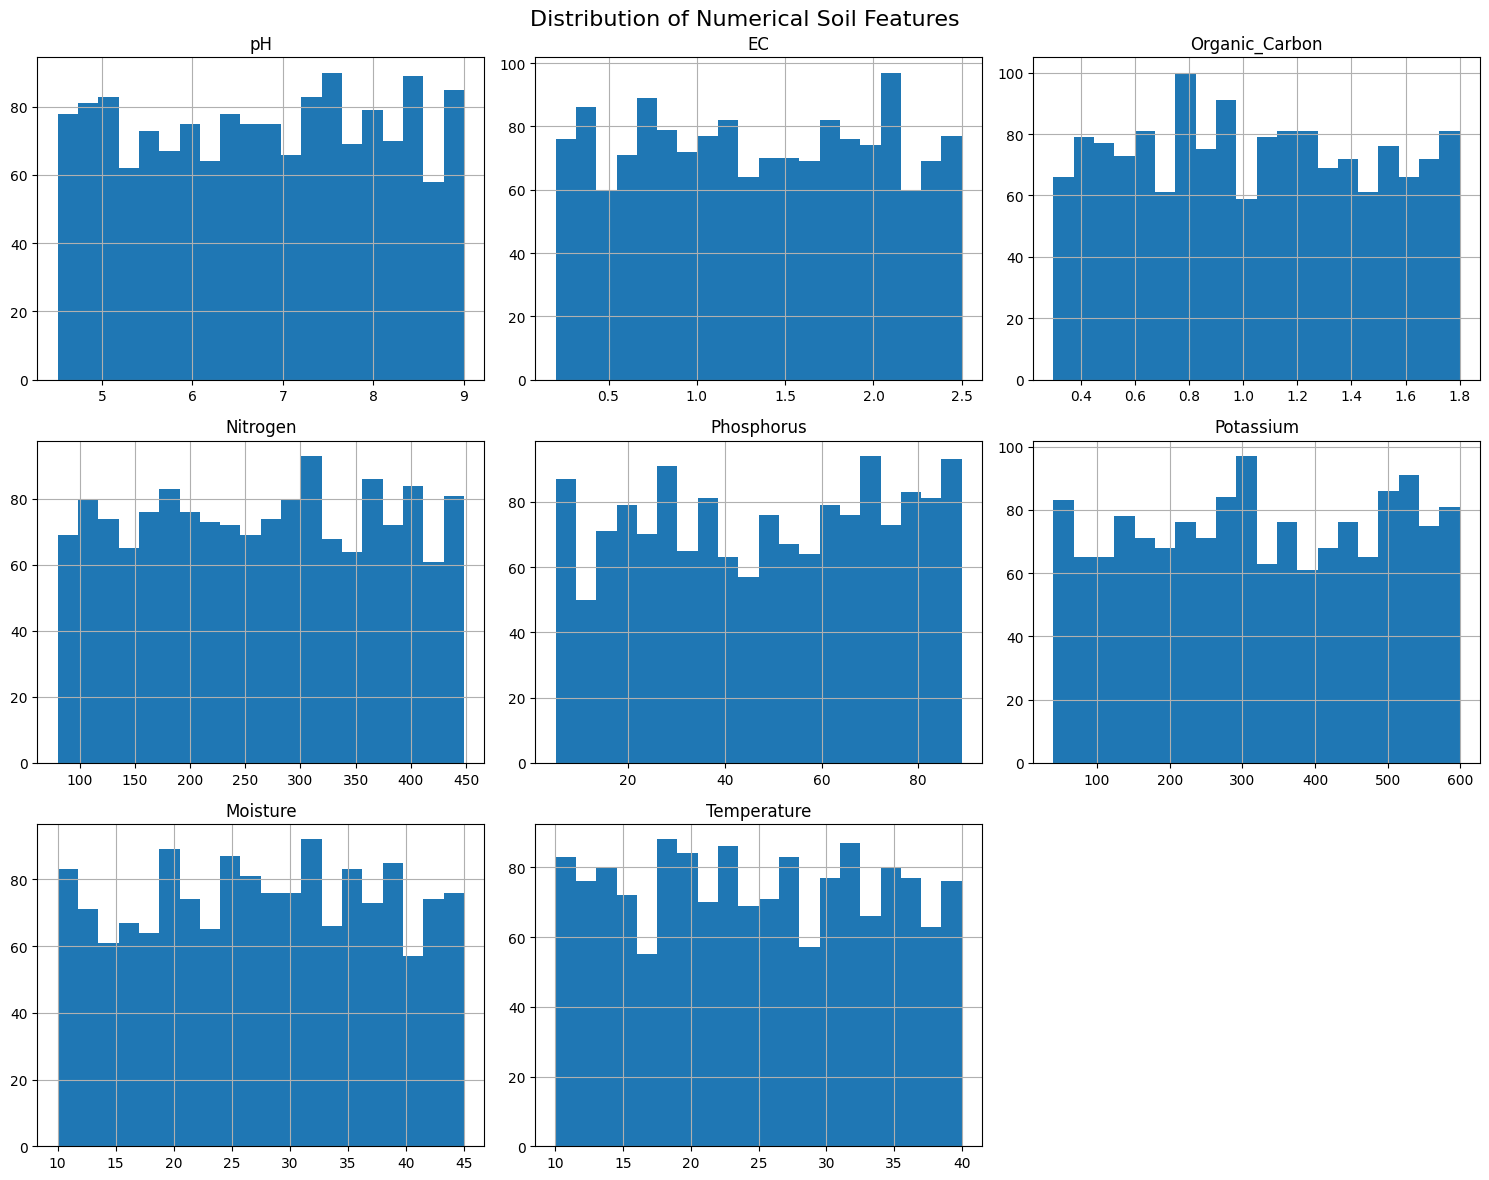

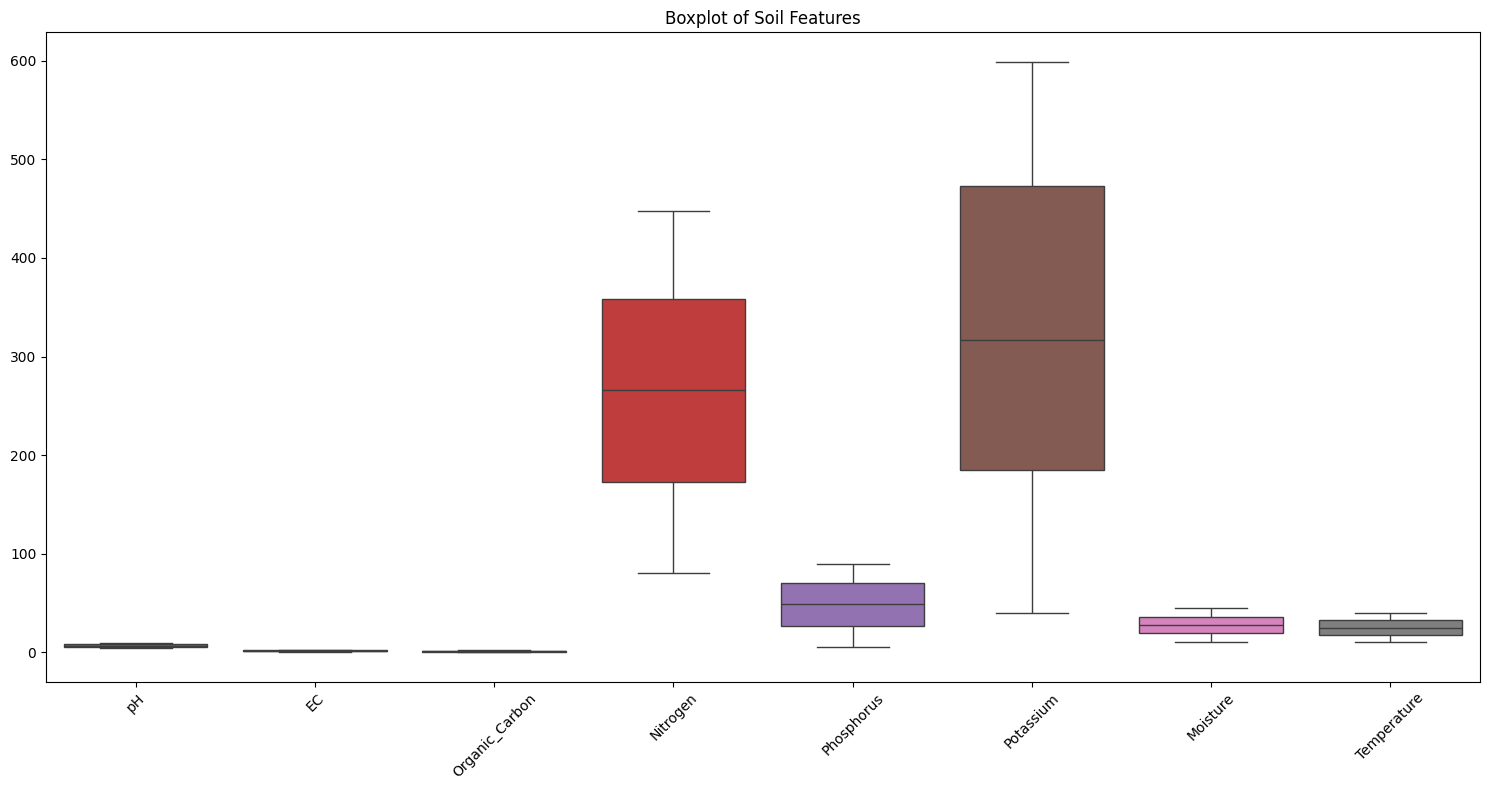


Correlation Matrix:
                      pH        EC  Organic_Carbon  Nitrogen  Phosphorus  \
pH              1.000000  0.025167        0.015472 -0.017335   -0.036088   
EC              0.025167  1.000000       -0.015361 -0.012236   -0.007046   
Organic_Carbon  0.015472 -0.015361        1.000000 -0.013452   -0.054670   
Nitrogen       -0.017335 -0.012236       -0.013452  1.000000    0.049554   
Phosphorus     -0.036088 -0.007046       -0.054670  0.049554    1.000000   
Potassium       0.027967  0.039531        0.009865  0.023352    0.023584   
Moisture       -0.025133 -0.015556        0.046387  0.035265    0.033884   
Temperature    -0.016131  0.022993        0.006698  0.006215    0.018349   

                Potassium  Moisture  Temperature  
pH               0.027967 -0.025133    -0.016131  
EC               0.039531 -0.015556     0.022993  
Organic_Carbon   0.009865  0.046387     0.006698  
Nitrogen         0.023352  0.035265     0.006215  
Phosphorus       0.023584  0.033884    

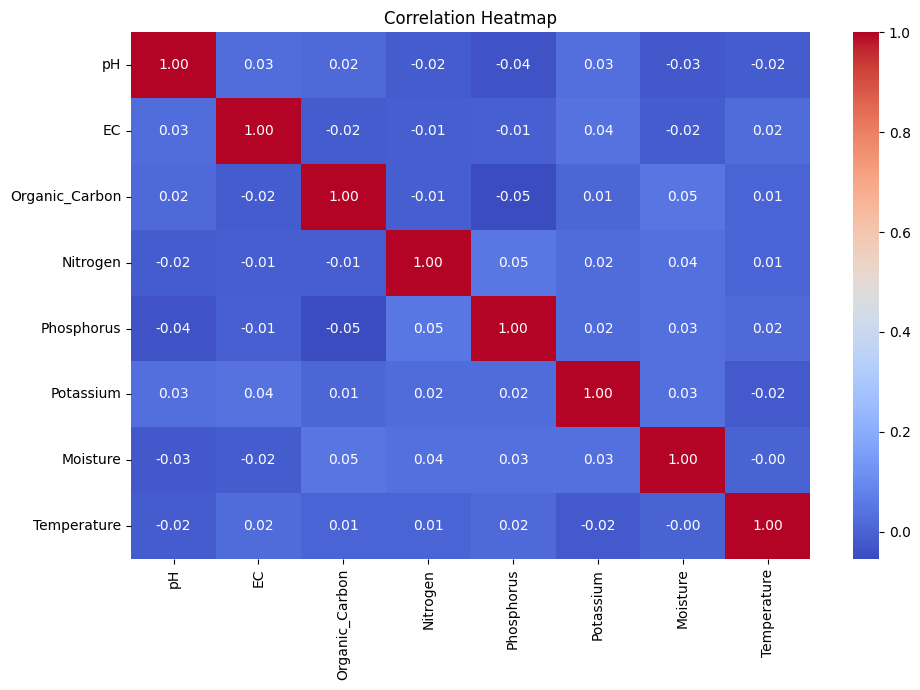

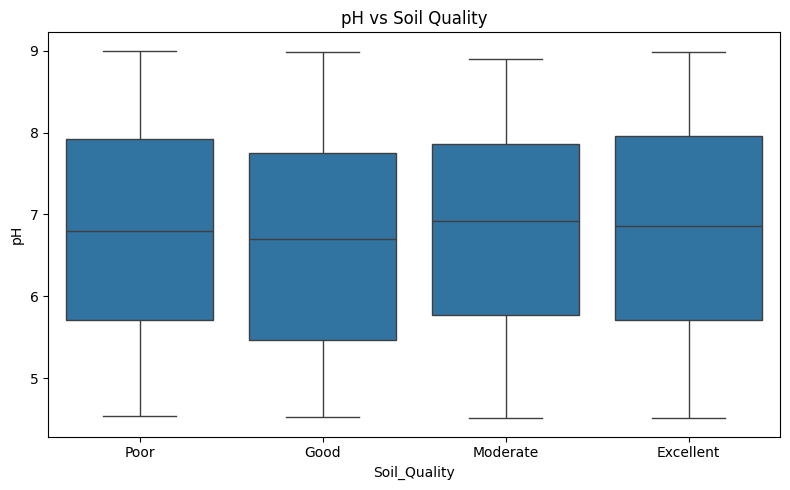

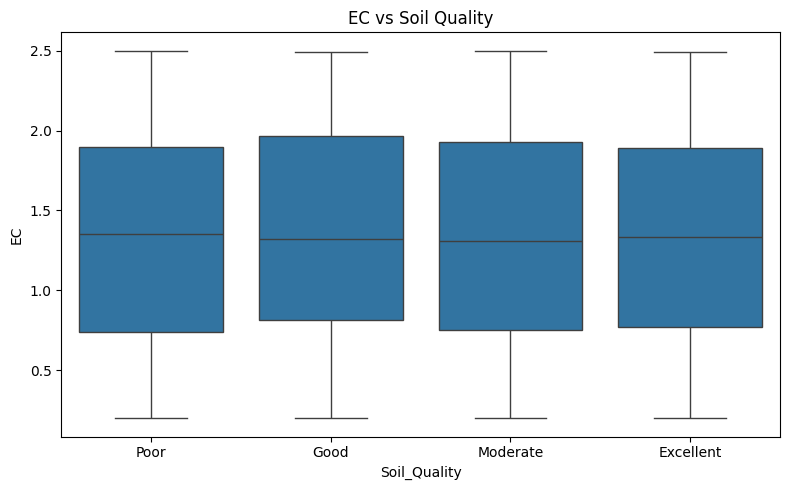

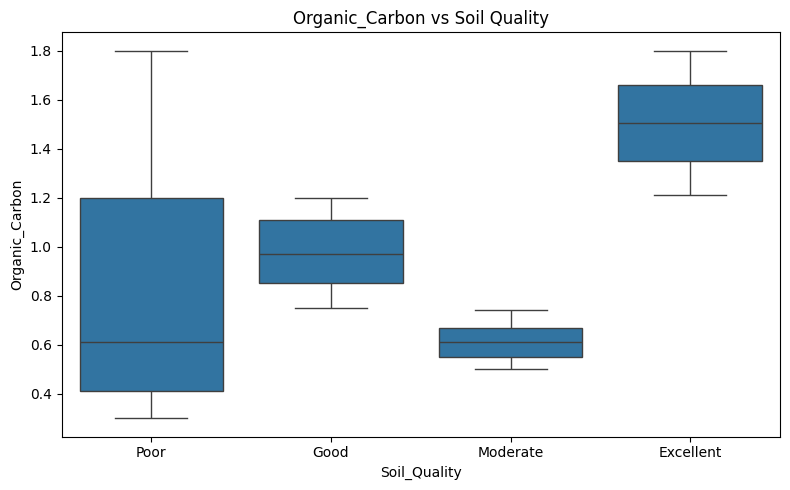

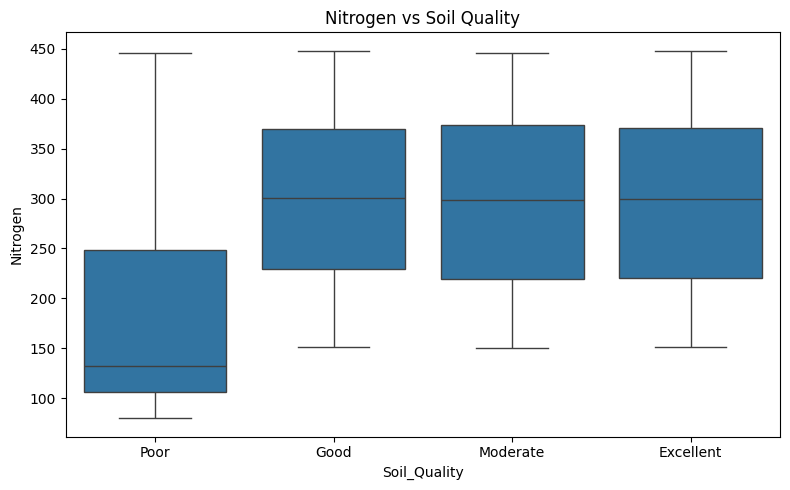

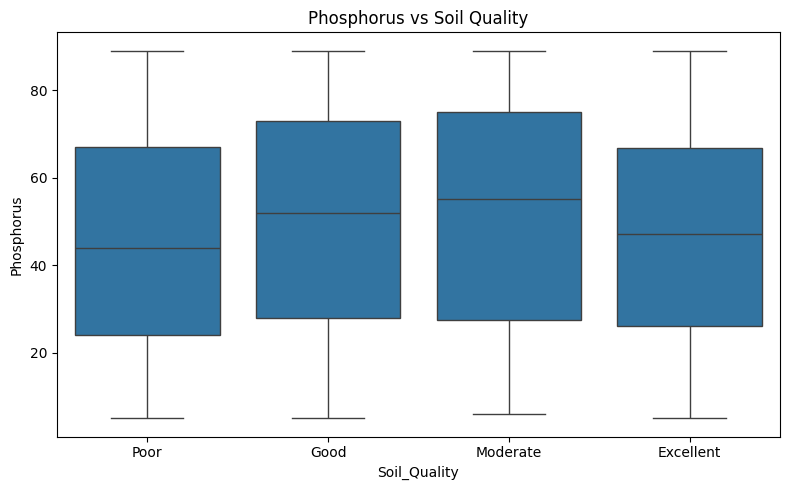

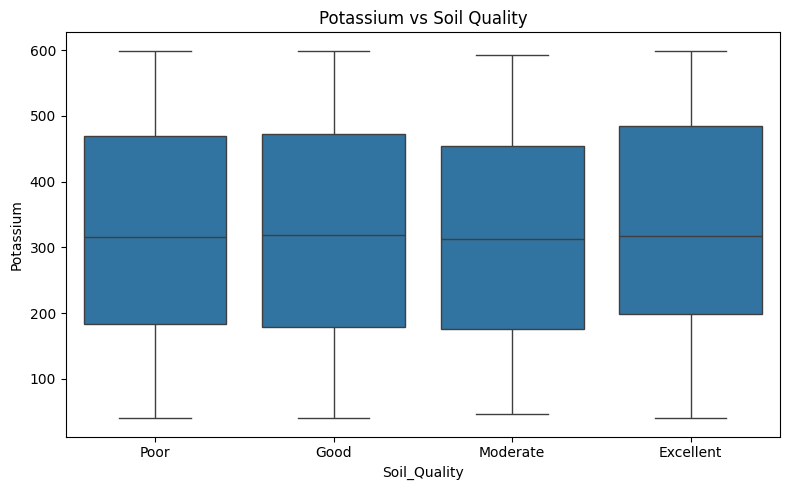

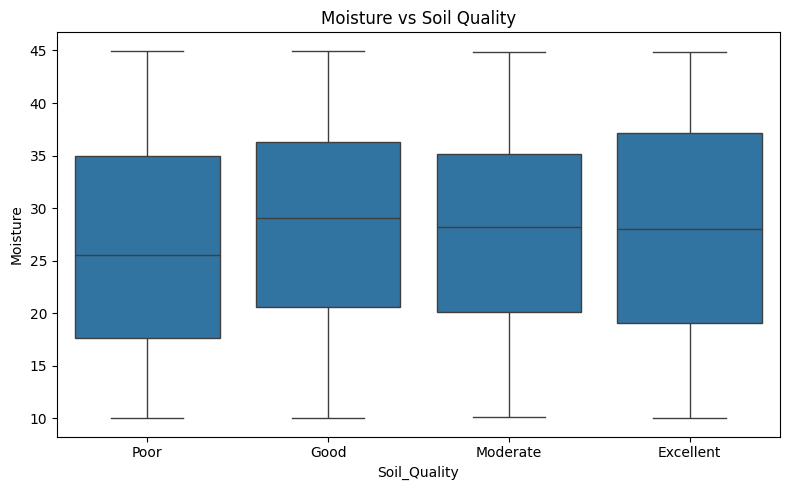

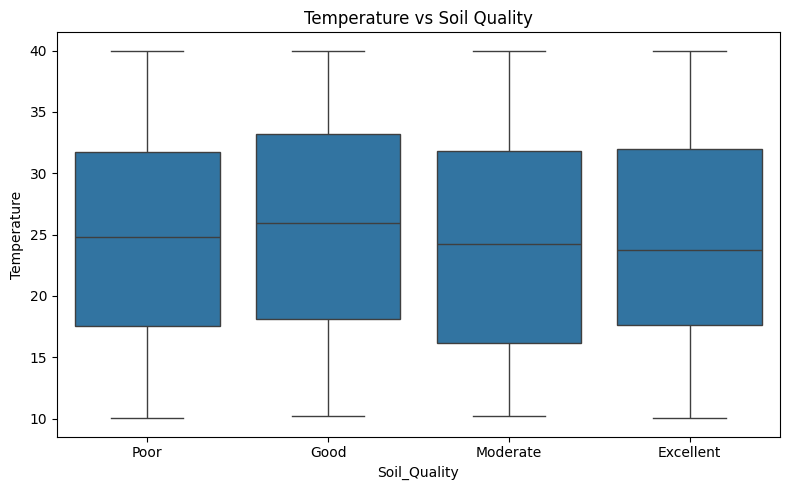


Soil Type vs Soil Quality:
Soil_Quality  Excellent  Good  Moderate  Poor
Soil_Type                                    
Clay                130   138        77   143
Loamy               159   130        57   146
Sandy               165   154        61   140


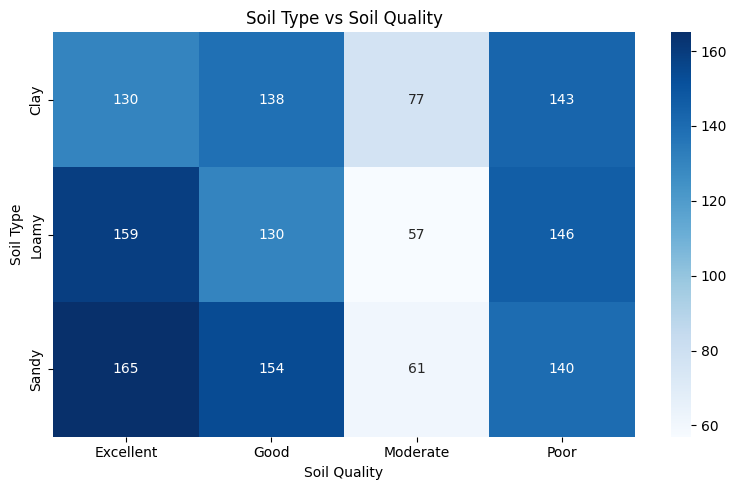


Mean Soil Parameters by Soil Quality:
                pH    EC  Organic_Carbon  Nitrogen  Phosphorus  Potassium  \
Soil_Quality                                                                
Excellent     6.83  1.33            1.51    297.06       46.86     331.25   
Good          6.65  1.36            0.98    299.85       50.27     321.85   
Moderate      6.82  1.32            0.62    297.77       51.93     315.80   
Poor          6.80  1.34            0.81    181.41       45.81     322.12   

              Moisture  Temperature  
Soil_Quality                         
Excellent        28.10        24.47  
Good             28.35        25.63  
Moderate         27.71        24.37  
Poor             26.24        24.77  

Outlier Count:
pH : 0
EC : 0
Organic_Carbon : 0
Nitrogen : 0
Phosphorus : 0
Potassium : 0
Moisture : 0
Temperature : 0

========== FINAL EDA SUMMARY ==========
Total Samples: 1500
Total Columns: 10
Input Features: 9
Missing Values: 0
Duplicate Rows: 0
Target Classes: 4

In [ ]:
# ============================================
# SOIL QUALITY CLASSIFICATION - EDA
# ============================================

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# --------------------------------------------
# 1. Load Dataset
# --------------------------------------------

df = pd.read_csv("soil_quality_dataset.csv")

print("First 5 rows:")
print(df.head())

# --------------------------------------------
# 2. Dataset Shape
# --------------------------------------------

print("\nDataset Shape:")
print(df.shape)

print("\nNumber of Rows:", df.shape[0])
print("Number of Columns:", df.shape[1])

# --------------------------------------------
# 3. Column Names
# --------------------------------------------

print("\nColumn Names:")
print(df.columns.tolist())

# --------------------------------------------
# 4. Dataset Information
# --------------------------------------------

print("\nDataset Information:")
df.info()

# --------------------------------------------
# 5. Data Types
# --------------------------------------------

print("\nData Types:")
print(df.dtypes)

# --------------------------------------------
# 6. Missing Values
# --------------------------------------------

print("\nMissing Values:")
print(df.isnull().sum())

# --------------------------------------------
# 7. Duplicate Values
# --------------------------------------------

print("\nNumber of Duplicate Rows:")
print(df.duplicated().sum())

# --------------------------------------------
# 8. Statistical Summary
# --------------------------------------------

print("\nStatistical Summary:")
print(df.describe())

# --------------------------------------------
# 9. Categorical Feature Analysis
# --------------------------------------------

print("\nSoil Type Distribution:")
print(df["Soil_Type"].value_counts())

print("\nSoil Quality Distribution:")
print(df["Soil_Quality"].value_counts())

# --------------------------------------------
# 10. Target Variable Visualization
# --------------------------------------------

plt.figure(figsize=(8, 5))

sns.countplot(
    data=df,
    x="Soil_Quality"
)

plt.title("Distribution of Soil Quality")
plt.xlabel("Soil Quality")
plt.ylabel("Number of Samples")
plt.tight_layout()
plt.show()

# --------------------------------------------
# 11. Soil Type Distribution
# --------------------------------------------

plt.figure(figsize=(7, 5))

sns.countplot(
    data=df,
    x="Soil_Type"
)

plt.title("Distribution of Soil Types")
plt.xlabel("Soil Type")
plt.ylabel("Number of Samples")
plt.tight_layout()
plt.show()

# --------------------------------------------
# 12. Numerical Features
# --------------------------------------------

numerical_features = df.select_dtypes(
    include=np.number
).columns

print("\nNumerical Features:")
print(numerical_features.tolist())

print("\nNumber of Numerical Features:",
      len(numerical_features))

# --------------------------------------------
# 13. Histograms
# --------------------------------------------

df[numerical_features].hist(
    figsize=(15, 12),
    bins=20
)

plt.suptitle(
    "Distribution of Numerical Soil Features",
    fontsize=16
)

plt.tight_layout()
plt.show()

# --------------------------------------------
# 14. Boxplots for Outlier Detection
# --------------------------------------------

plt.figure(figsize=(15, 8))

sns.boxplot(
    data=df[numerical_features]
)

plt.title("Boxplot of Soil Features")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

# --------------------------------------------
# 15. Correlation Matrix
# --------------------------------------------

correlation = df[numerical_features].corr()

print("\nCorrelation Matrix:")
print(correlation)

plt.figure(figsize=(10, 7))

sns.heatmap(
    correlation,
    annot=True,
    cmap="coolwarm",
    fmt=".2f"
)

plt.title("Correlation Heatmap")
plt.tight_layout()
plt.show()

# --------------------------------------------
# 16. Feature vs Soil Quality
# --------------------------------------------

for feature in numerical_features:

    plt.figure(figsize=(8, 5))

    sns.boxplot(
        data=df,
        x="Soil_Quality",
        y=feature
    )

    plt.title(
        f"{feature} vs Soil Quality"
    )

    plt.tight_layout()
    plt.show()

# --------------------------------------------
# 17. Soil Type vs Soil Quality
# --------------------------------------------

cross_table = pd.crosstab(
    df["Soil_Type"],
    df["Soil_Quality"]
)

print("\nSoil Type vs Soil Quality:")
print(cross_table)

plt.figure(figsize=(8, 5))

sns.heatmap(
    cross_table,
    annot=True,
    fmt="d",
    cmap="Blues"
)

plt.title("Soil Type vs Soil Quality")
plt.xlabel("Soil Quality")
plt.ylabel("Soil Type")
plt.tight_layout()
plt.show()

# --------------------------------------------
# 18. Mean Values by Soil Quality
# --------------------------------------------

mean_values = df.groupby(
    "Soil_Quality"
)[numerical_features].mean()

print("\nMean Soil Parameters by Soil Quality:")
print(mean_values.round(2))

# --------------------------------------------
# 19. Outlier Count using IQR
# --------------------------------------------

print("\nOutlier Count:")

for feature in numerical_features:

    Q1 = df[feature].quantile(0.25)
    Q3 = df[feature].quantile(0.75)

    IQR = Q3 - Q1

    lower = Q1 - 1.5 * IQR
    upper = Q3 + 1.5 * IQR

    outliers = df[
        (df[feature] < lower) |
        (df[feature] > upper)
    ]

    print(feature, ":", len(outliers))

# --------------------------------------------
# 20. Final Dataset Summary
# --------------------------------------------

print("\n========== FINAL EDA SUMMARY ==========")

print("Total Samples:", df.shape[0])
print("Total Columns:", df.shape[1])
print("Input Features:", df.shape[1] - 1)
print("Missing Values:", df.isnull().sum().sum())
print("Duplicate Rows:", df.duplicated().sum())
print("Target Classes:",
      df["Soil_Quality"].nunique())

print("\nTarget Classes:")
print(df["Soil_Quality"].unique())
